# House Price Prediction: Comparing Preprocessing Strategies for MLP Regression

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Aprendizado Supervisionado<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** July 8, 2025   

---

## 1. Introduction & Objectives

**Problem:**  
Predicting residential property sale prices is a classic regression task in real estate analytics. The challenge lies not only in choosing the right model architecture, but in how raw features are transformed before training.

**Task Type:**  
Supervised Learning, Regression

**Objective:**  
This notebook evaluates the impact of three preprocessing strategies on the predictive performance of a fixed MLP architecture. The strategies compared are feature encoding, feature selection, and feature engineering. All experiments use the same model and training procedure to isolate the effect of preprocessing.

**Primary Evaluation Metrics:**  
MAE (Mean Absolute Error) and R² (Coefficient of Determination)

**Success Criteria:**  
Models achieving R² > 0.95 and MAE below R$ 15,000 on the test set are considered successful.

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import warnings
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Environment ready")
print("Pandas version:", pd.__version__)
print("PyTorch version:", torch.__version__)

Environment ready
Pandas version: 3.0.1
PyTorch version: 2.10.0+cpu


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
Local file `casas.csv` (synthetic residential property dataset)

**Description:**  
Each row represents a residential property described by structural and location attributes. The goal is to predict its sale price.

**Features:**

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | Area_m2 | Numerical | Property area in square meters |
| 2 | Num_Quartos | Numerical | Number of bedrooms |
| 3 | Num_Banheiros | Numerical | Number of bathrooms |
| 4 | Idade_Casa_Anos | Numerical | Property age in years |
| 5 | Localizacao | Categorical | Neighborhood zone (A, B, or C) |
| 6 | Garagem | Binary | Presence of a garage (Sim / Nao) |

**Target Variable:**  
`Preco_Venda` — Sale price in Brazilian Real (R$)

**Unit of Analysis:**  
Individual residential property

In [2]:
df = pd.read_csv("dataset/casas.csv")

print("Shape:", df.shape)
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (30, 7)


,Area_m2,Num_Quartos,Num_Banheiros,Idade_Casa_Anos,Localizacao,Garagem,Preco_Venda
0,120,3,2,5,A,Sim,350000
1,85,2,1,10,B,Nao,220000
2,200,4,3,2,A,Sim,550000
3,150,3,2,8,C,Sim,400000
4,95,2,2,15,B,Sim,280000



Data types:


Area_m2            int64
Num_Quartos        int64
Num_Banheiros      int64
Idade_Casa_Anos    int64
Localizacao          str
Garagem              str
Preco_Venda        int64
dtype: object


Missing values:


Area_m2            0
Num_Quartos        0
Num_Banheiros      0
Idade_Casa_Anos    0
Localizacao        0
Garagem            0
Preco_Venda        0
dtype: int64


Summary statistics:


,Area_m2,Num_Quartos,Num_Banheiros,Idade_Casa_Anos,Preco_Venda
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,139.833333,3.000000,2.033333,9.200000,384333.333333
std,47.642406,1.114172,0.927857,6.743579,139424.515069
min,65.000000,1.000000,1.000000,0.000000,170000.000000
25%,101.250000,2.000000,1.000000,4.000000,282500.000000
50%,137.500000,3.000000,2.000000,7.500000,375000.000000
75%,173.750000,4.000000,3.000000,13.750000,477500.000000
max,230.000000,5.000000,4.000000,25.000000,680000.000000


## 4. Exploratory Data Analysis (EDA)

Goals:

- Understand distributions of numerical features
- Examine how categorical variables relate to sale price
- Identify correlations between features and the target
- Detect potential multicollinearity or redundant features

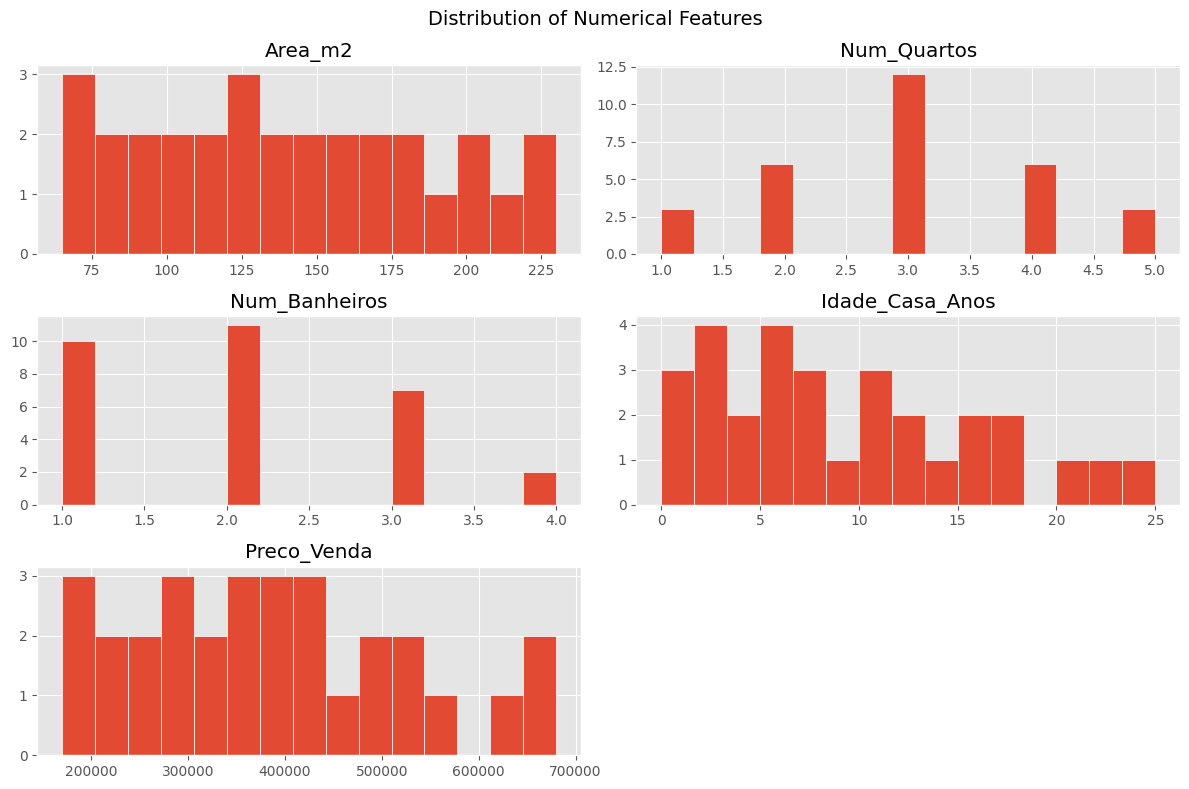

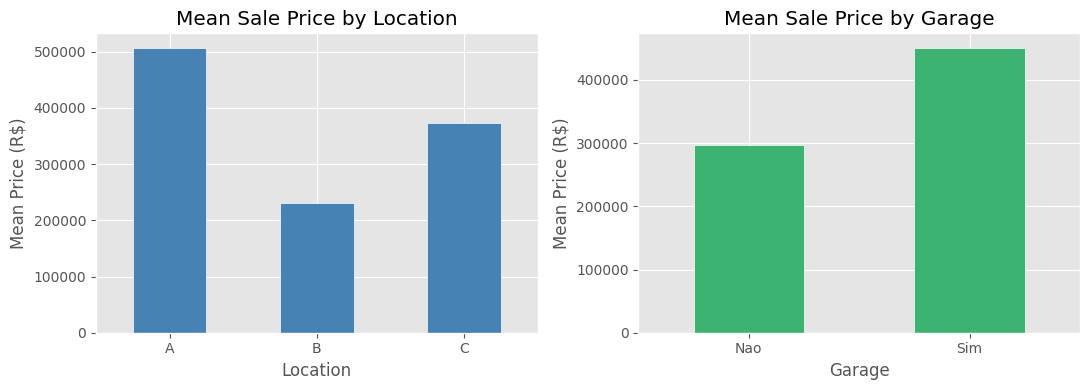

In [3]:
# Distributions of numerical features
num_features = ["Area_m2", "Num_Quartos", "Num_Banheiros", "Idade_Casa_Anos", "Preco_Venda"]

df[num_features].hist(figsize=(12, 8), bins=15, edgecolor="white")
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

# Mean sale price by categorical features
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.groupby("Localizacao")["Preco_Venda"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Mean Sale Price by Location")
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Mean Price (R$)")
axes[0].tick_params(axis="x", rotation=0)

df.groupby("Garagem")["Preco_Venda"].mean().plot(
    kind="bar", ax=axes[1], color="mediumseagreen", edgecolor="white"
)
axes[1].set_title("Mean Sale Price by Garage")
axes[1].set_xlabel("Garage")
axes[1].set_ylabel("Mean Price (R$)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

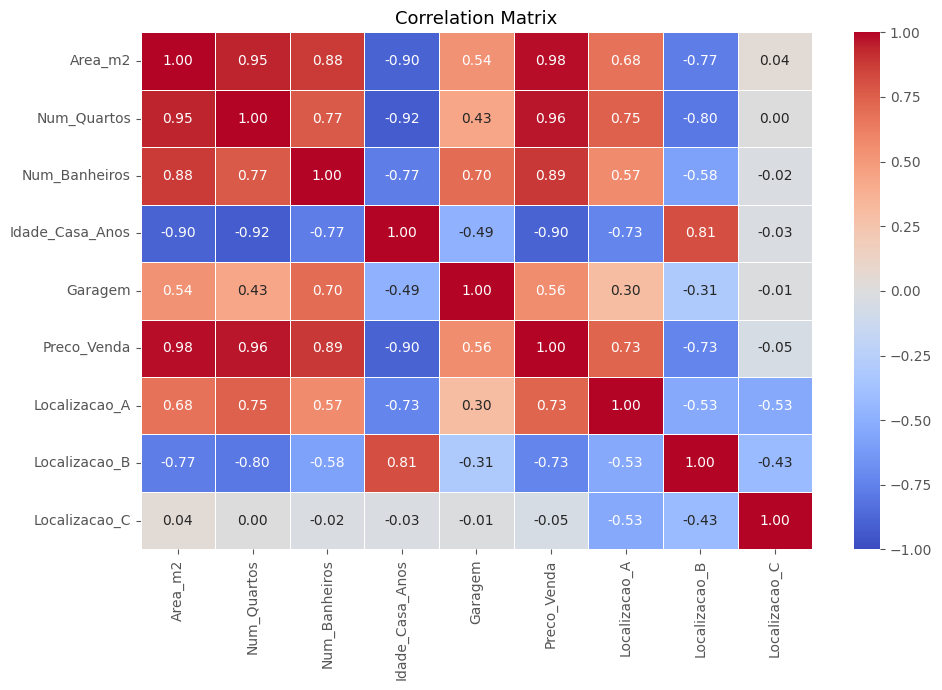


Correlation with Preco_Venda:


Area_m2            0.984367
Num_Quartos        0.963386
Num_Banheiros      0.886462
Localizacao_A      0.733618
Garagem            0.557612
Localizacao_C     -0.052532
Localizacao_B     -0.731738
Idade_Casa_Anos   -0.898395
Name: Preco_Venda, dtype: float64

In [4]:
# Encode categoricals temporarily for correlation analysis
df_corr = df.copy()
df_corr["Garagem"] = df_corr["Garagem"].map({"Sim": 1, "Nao": 0})
df_corr = pd.get_dummies(df_corr, columns=["Localizacao"], drop_first=False)

bool_cols = df_corr.select_dtypes(include="bool").columns
df_corr[bool_cols] = df_corr[bool_cols].astype(int)

corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

print("\nCorrelation with Preco_Venda:")
display(corr_matrix["Preco_Venda"].drop("Preco_Venda").sort_values(ascending=False))

### EDA Findings

- `Area_m2`, `Num_Quartos`, and `Num_Banheiros` show strong positive correlation with sale price.
- `Idade_Casa_Anos` is negatively correlated with price: older properties tend to be valued lower.
- Properties in location A command higher prices; location B is associated with below-average values.
- `Num_Quartos` and `Num_Banheiros` are moderately correlated with each other, suggesting potential benefit from combining them into a single feature.
- `Garagem` has a moderate positive association with price and introduces a natural area extension when present.

These patterns directly motivate the feature engineering choices explored in Strategy 3.

## 5. Model Architecture & Helper Functions

The same MLP is used across all three preprocessing strategies. This design controls for architecture effects and isolates the impact of preprocessing.

Architecture:

- Input layer: variable dimension (depends on preprocessing strategy)
- Hidden layer 1: 32 units, ReLU activation, Dropout(0.1)
- Hidden layer 2: 16 units, ReLU activation, Dropout(0.1)
- Output layer: 1 unit (continuous regression output)

Training configuration:

- Loss function: Mean Squared Error (MSE)
- Optimizer: Adam (lr=0.01, weight_decay=1e-5)
- Epochs: 200, Batch size: 16
- Target variable is standardized before training and inverse-transformed for evaluation

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [6]:
def calculate_metrics(y_true, y_pred):
    """Compute MSE, MAE, and R² between arrays of true and predicted values."""
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def calculate_errors(y_true, y_pred):
    """Return a list of per-sample prediction details with absolute and percentage errors."""
    rows = []
    for true_val, pred_val in zip(y_true, y_pred):
        abs_err = abs(true_val - pred_val)
        pct_err = (abs_err / true_val) * 100 if true_val != 0 else 0
        rows.append({
            "Predicted Price (R$)": f"{int(round(pred_val)):,}",
            "Actual Price (R$)": f"{int(round(true_val)):,}",
            "Absolute Error (R$)": abs_err,
            "Percentage Error (%)": pct_err,
            "_pred": pred_val,
            "_actual": true_val,
        })
    return rows


def train_model(train_loader, input_dim):
    """Train the MLP for 200 epochs using MSE loss and the Adam optimizer."""
    model = MLP(input_dim)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)
    loss_history = []

    for epoch in range(200):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append({"epoch": epoch + 1, "loss": epoch_loss / len(train_loader)})

    return model, loss_history


def eval_model(model, X_test_tensor, y_test_tensor, scaler_y):
    """Evaluate the model on the test set; returns metrics dict and per-sample error list."""
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor)

    y_true = scaler_y.inverse_transform(y_test_tensor.cpu().numpy()).flatten()
    y_pred = scaler_y.inverse_transform(preds.cpu().numpy()).flatten()

    return calculate_metrics(y_true, y_pred), calculate_errors(y_true, y_pred)


def eval_train_test_metrics(model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler_y):
    """Compute and return metrics for both the training and test sets."""
    model.eval()
    with torch.no_grad():
        preds_train = model(X_train_tensor)
        preds_test = model(X_test_tensor)

    y_train_true = scaler_y.inverse_transform(y_train_tensor.cpu().numpy()).flatten()
    y_train_pred = scaler_y.inverse_transform(preds_train.cpu().numpy()).flatten()
    y_test_true = scaler_y.inverse_transform(y_test_tensor.cpu().numpy()).flatten()
    y_test_pred = scaler_y.inverse_transform(preds_test.cpu().numpy()).flatten()

    return calculate_metrics(y_train_true, y_train_pred), calculate_metrics(y_test_true, y_test_pred)

In [7]:
def plot_predictions(error_data, title_suffix=""):
    """Display per-sample prediction table and actual vs predicted scatter plot."""
    df_err = pd.DataFrame(error_data)

    display_df = df_err[
        ["Predicted Price (R$)", "Actual Price (R$)", "Absolute Error (R$)", "Percentage Error (%)"]
    ].copy()
    display_df["Absolute Error (R$)"] = display_df["Absolute Error (R$)"].apply(
        lambda x: f"{int(round(x)):,}"
    )
    display_df["Percentage Error (%)"] = display_df["Percentage Error (%)"].apply(
        lambda x: f"{x:.2f}"
    )
    print("Prediction table:")
    display(display_df)

    plt.figure(figsize=(6, 4))
    plt.scatter(df_err["_actual"], df_err["_pred"], alpha=0.7)
    min_val = min(df_err["_actual"].min(), df_err["_pred"].min())
    max_val = max(df_err["_actual"].max(), df_err["_pred"].max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Ideal")
    plt.xlabel("Actual Price (R$)")
    plt.ylabel("Predicted Price (R$)")
    plt.title(f"Actual vs Predicted{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_loss_curve(loss_history, title_suffix=""):
    """Plot training loss over epochs."""
    df_loss = pd.DataFrame(loss_history)
    plt.figure(figsize=(6, 4))
    plt.plot(df_loss["epoch"], df_loss["loss"], color="steelblue", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.title(f"Training Loss Curve{title_suffix}")
    plt.tight_layout()
    plt.show()


def plot_metric_bar(df, metric_col, ylabel, title, color):
    """Bar chart comparing a metric across strategies."""
    plt.figure(figsize=(6, 4))
    plt.bar(df["Model"], df[metric_col], color=color, edgecolor="white")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Strategy")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def plot_metric_over_runs(df_runs, metric_col, title, model_colors):
    """Line chart showing a metric across multiple training runs for each strategy."""
    plt.figure(figsize=(10, 5))
    for model_name, color in model_colors.items():
        subset = df_runs[df_runs["Model"] == model_name]
        plt.plot(
            subset["Run"], subset[metric_col],
            label=model_name, marker="o", markersize=3, color=color
        )
    plt.title(title)
    plt.xlabel("Run")
    plt.ylabel(metric_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Preprocessing & Model Training

Three preprocessing strategies are applied to the same raw dataset. Each strategy is followed by training and evaluating the MLP on an 80/20 train/test split (random_state=42).

The results of each strategy are accumulated for comparison in Section 7.

In [8]:
# Storage for preprocessed tensors and single-run results across all strategies
preprocessing_configs = []
single_run_results = []

### Strategy 1: Feature Encoding

Categorical variables are encoded for compatibility with the MLP:

- `Garagem` is mapped to a binary integer (1 = garage present, 0 = absent).
- `Localizacao` is one-hot encoded into three indicator columns.
- Numerical features are standardized using `StandardScaler` (fit on the training set only, applied to both sets to prevent data leakage).
- The target `Preco_Venda` is also standardized to improve gradient scaling during training.

In [9]:
X = df.drop("Preco_Venda", axis=1).copy()
y = df["Preco_Venda"].values

X["Garagem"] = X["Garagem"].map({"Sim": 1, "Nao": 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

num_cols = ["Area_m2", "Num_Quartos", "Num_Banheiros", "Idade_Casa_Anos"]

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(X_train[num_cols])
X_test_num = scaler_X.transform(X_test[num_cols])

encoder = OneHotEncoder(sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[["Localizacao"]])
X_test_cat = encoder.transform(X_test[["Localizacao"]])

X_train_gar = X_train[["Garagem"]].values.astype(float)
X_test_gar = X_test[["Garagem"]].values.astype(float)

X_train_proc = np.hstack([X_train_num, X_train_gar, X_train_cat])
X_test_proc = np.hstack([X_test_num, X_test_gar, X_test_cat])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

feature_names_enc = num_cols + ["Garagem"] + list(encoder.get_feature_names_out(["Localizacao"]))
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)

preprocessing_configs.append({
    "title": "Feature Encoding",
    "X_train_tensor": X_train_tensor,
    "X_test_tensor": X_test_tensor,
    "y_train_tensor": y_train_tensor,
    "y_test_tensor": y_test_tensor,
    "train_loader": train_loader,
    "scaler_y": scaler_y,
    "feature_names": feature_names_enc
})

print(f"Feature Encoding: {X_train_tensor.shape[1]} input features")
display(pd.DataFrame(X_train_proc, columns=feature_names_enc).head())

Feature Encoding: 8 input features


,Area_m2,Num_Quartos,Num_Banheiros,Idade_Casa_Anos,Garagem,Localizacao_A,Localizacao_B,Localizacao_C
0,-1.576153,-1.931135,-1.063410,2.369438,0.0,0.0,1.0,0.0
1,-1.232265,-0.901196,-1.063410,1.119625,0.0,0.0,1.0,0.0
2,1.289580,1.158681,1.256757,-0.911322,1.0,1.0,0.0,0.0
3,-0.315231,0.128742,0.096674,-0.755096,1.0,1.0,0.0,0.0
4,-0.888377,-0.901196,0.096674,0.807171,1.0,0.0,1.0,0.0


Train vs Test Metrics - Feature Encoding:


,Set,MSE,MAE,R2
0,Train,2.781249e+08,11850.285156,0.981175
1,Test,1.993965e+09,37212.707031,0.925390


Prediction table:


,Predicted Price (R$),Actual Price (R$),Absolute Error (R$),Percentage Error (%)
0,"605,138","680,000","74,862",11.01
1,"456,629","500,000","43,371",8.67
2,"377,778","390,000","12,222",3.13
3,"558,013","620,000","61,987",10.00
4,"197,795","180,000","17,795",9.89
5,"406,961","420,000","13,039",3.10


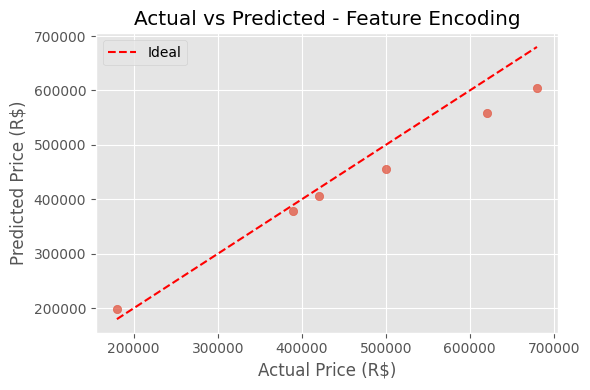

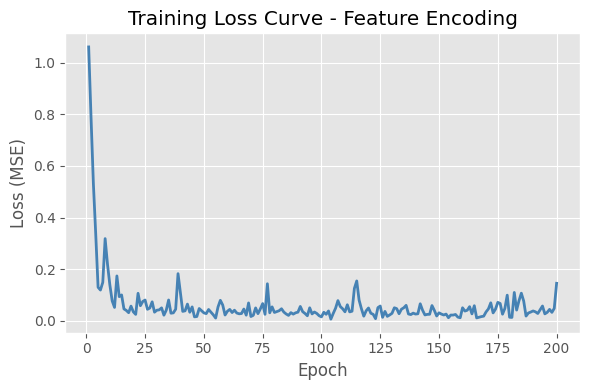

In [10]:
torch.manual_seed(SEED)
model_enc, loss_history_enc = train_model(train_loader, X_train_tensor.shape[1])
metrics_enc, errors_enc = eval_model(model_enc, X_test_tensor, y_test_tensor, scaler_y)

metrics_train_enc, metrics_test_enc = eval_train_test_metrics(
    model_enc, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler_y
)

single_run_results.append({
    "title": "Feature Encoding",
    "metrics": metrics_enc,
    "errors": errors_enc
})

print("Train vs Test Metrics - Feature Encoding:")
display(pd.DataFrame([
    {"Set": "Train", **metrics_train_enc},
    {"Set": "Test", **metrics_test_enc}
]))

plot_predictions(errors_enc, " - Feature Encoding")
plot_loss_curve(loss_history_enc, " - Feature Encoding")

### Strategy 2: Feature Selection

Instead of using all encoded features, `SelectKBest` with `f_regression` retains only the 5 features most statistically associated with the target, as measured by the F-statistic from a linear regression.

The motivation is to reduce model complexity and potentially improve generalization by discarding low-relevance or redundant variables. The selector is fit on the training set only.

In [11]:
X = df.drop("Preco_Venda", axis=1).copy()
y = df["Preco_Venda"].values

X["Garagem"] = X["Garagem"].map({"Sim": 1, "Nao": 0})
X = pd.get_dummies(X, columns=["Localizacao"], drop_first=False)

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

num_cols = ["Area_m2", "Num_Quartos", "Num_Banheiros", "Idade_Casa_Anos"]
bin_cols = ["Garagem", "Localizacao_A", "Localizacao_B", "Localizacao_C"]
all_cols = num_cols + bin_cols

X_train, X_test, y_train, y_test = train_test_split(X[all_cols], y, test_size=0.2, random_state=SEED)

scaler_X = StandardScaler()
X_train_num = scaler_X.fit_transform(X_train[num_cols])
X_test_num = scaler_X.transform(X_test[num_cols])

X_train_bin = X_train[bin_cols].values.astype(float)
X_test_bin = X_test[bin_cols].values.astype(float)

X_train_combined = np.hstack([X_train_num, X_train_bin])
X_test_combined = np.hstack([X_test_num, X_test_bin])

selector = SelectKBest(score_func=f_regression, k=5)
X_train_sel = selector.fit_transform(X_train_combined, y_train).astype(float)
X_test_sel = selector.transform(X_test_combined).astype(float)

selected_features = [all_cols[i] for i in selector.get_support(indices=True)]
print("Selected features:", selected_features)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_sel, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_sel, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)

preprocessing_configs.append({
    "title": "Feature Selection",
    "X_train_tensor": X_train_tensor,
    "X_test_tensor": X_test_tensor,
    "y_train_tensor": y_train_tensor,
    "y_test_tensor": y_test_tensor,
    "train_loader": train_loader,
    "scaler_y": scaler_y,
    "feature_names": selected_features
})

print(f"Feature Selection: {X_train_tensor.shape[1]} input features")
display(pd.DataFrame(X_train_sel, columns=selected_features).head())

Selected features: ['Area_m2', 'Num_Quartos', 'Num_Banheiros', 'Idade_Casa_Anos', 'Localizacao_B']
Feature Selection: 5 input features


,Area_m2,Num_Quartos,Num_Banheiros,Idade_Casa_Anos,Localizacao_B
0,-1.576153,-1.931135,-1.063410,2.369438,1.0
1,-1.232265,-0.901196,-1.063410,1.119625,1.0
2,1.289580,1.158681,1.256757,-0.911322,0.0
3,-0.315231,0.128742,0.096674,-0.755096,0.0
4,-0.888377,-0.901196,0.096674,0.807171,1.0


Train vs Test Metrics - Feature Selection:


,Set,MSE,MAE,R2
0,Train,2.107423e+08,9984.597656,0.985736
1,Test,1.264567e+09,27341.220703,0.952682


Prediction table:


,Predicted Price (R$),Actual Price (R$),Absolute Error (R$),Percentage Error (%)
0,"617,701","680,000","62,299",9.16
1,"462,184","500,000","37,816",7.56
2,"385,011","390,000","4,989",1.28
3,"574,152","620,000","45,848",7.39
4,"179,089","180,000",911,0.51
5,"407,815","420,000","12,185",2.90


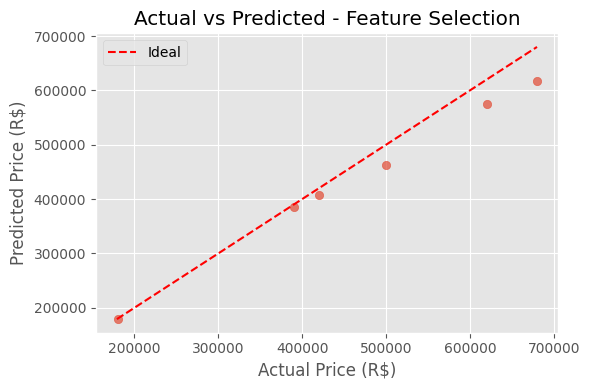

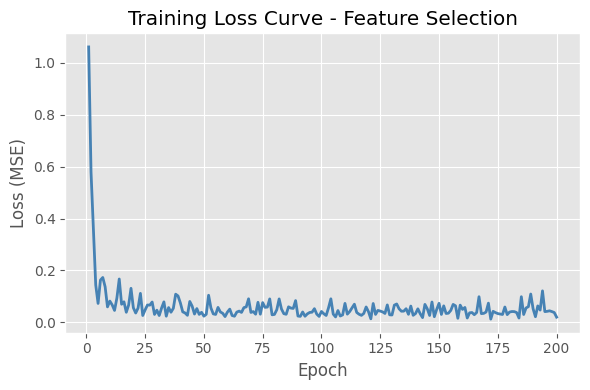

In [12]:
torch.manual_seed(SEED)
model_sel, loss_history_sel = train_model(train_loader, X_train_tensor.shape[1])
metrics_sel, errors_sel = eval_model(model_sel, X_test_tensor, y_test_tensor, scaler_y)

metrics_train_sel, metrics_test_sel = eval_train_test_metrics(
    model_sel, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler_y
)

single_run_results.append({
    "title": "Feature Selection",
    "metrics": metrics_sel,
    "errors": errors_sel
})

print("Train vs Test Metrics - Feature Selection:")
display(pd.DataFrame([
    {"Set": "Train", **metrics_train_sel},
    {"Set": "Test", **metrics_test_sel}
]))

plot_predictions(errors_sel, " - Feature Selection")
plot_loss_curve(loss_history_sel, " - Feature Selection")

### Strategy 3: Feature Engineering

Domain-informed transformations and new composite features are created before training:

- `log_Area_m2`: log-transform of `Area_m2`. Price scales sub-linearly with area, making a log transformation more appropriate.
- `sqrt_Idade_Casa`: square root of `Idade_Casa_Anos`. Depreciation tends to be faster in newer properties and decelerates as the house ages.
- `Comodos_Totais`: sum of `Num_Quartos` and `Num_Banheiros`, consolidating two correlated room-count features into a single measure of internal space.
- `log_Area_Total`: log-transform of the effective total area, adding 35 m² when a garage is present to capture its structural contribution.
- `Localizacao_A` and `Localizacao_B` are retained as binary location indicators.

This approach reduces dimensionality while injecting domain knowledge, which is particularly important for small datasets where the model has limited capacity to discover complex patterns independently.

In [13]:
X = df.drop("Preco_Venda", axis=1).copy()
y = df["Preco_Venda"].values

X["Garagem"] = X["Garagem"].map({"Sim": 1, "Nao": 0})

X["Comodos_Totais"] = X["Num_Quartos"] + X["Num_Banheiros"]
X["log_Area_m2"] = np.log1p(X["Area_m2"])
X["log_Area_Total"] = np.log1p(X["Area_m2"] + X["Garagem"] * 35)
X["sqrt_Idade_Casa"] = np.sqrt(X["Idade_Casa_Anos"])

X = pd.get_dummies(X, columns=["Localizacao"], drop_first=False)

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

final_cols = ["log_Area_m2", "sqrt_Idade_Casa", "Comodos_Totais", "log_Area_Total", "Localizacao_A", "Localizacao_B"]
continuous_cols = ["log_Area_m2", "sqrt_Idade_Casa", "Comodos_Totais", "log_Area_Total"]
binary_cols = ["Localizacao_A", "Localizacao_B"]

X_train, X_test, y_train, y_test = train_test_split(X[final_cols], y, test_size=0.2, random_state=SEED)

scaler_X = StandardScaler()
X_train_cont = scaler_X.fit_transform(X_train[continuous_cols])
X_test_cont = scaler_X.transform(X_test[continuous_cols])

X_train_bin = X_train[binary_cols].values.astype(float)
X_test_bin = X_test[binary_cols].values.astype(float)

X_train_proc = np.hstack([X_train_cont, X_train_bin])
X_test_proc = np.hstack([X_test_cont, X_test_bin])

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=16, shuffle=True)

preprocessing_configs.append({
    "title": "Feature Engineering",
    "X_train_tensor": X_train_tensor,
    "X_test_tensor": X_test_tensor,
    "y_train_tensor": y_train_tensor,
    "y_test_tensor": y_test_tensor,
    "train_loader": train_loader,
    "scaler_y": scaler_y,
    "feature_names": final_cols
})

print(f"Feature Engineering: {X_train_tensor.shape[1]} input features")
display(pd.DataFrame(X_train_proc, columns=final_cols).head())

Feature Engineering: 6 input features


,log_Area_m2,sqrt_Idade_Casa,Comodos_Totais,log_Area_Total,Localizacao_A,Localizacao_B
0,-1.981691,1.952782,-1.635119,-2.064811,0.0,1.0
1,-1.366502,1.115039,-1.049405,-1.515348,0.0,1.0
2,1.210346,-0.913276,1.293453,1.237636,1.0,0.0
3,-0.160899,-0.687748,0.122024,0.243106,1.0,0.0
4,-0.856137,0.876084,-0.463691,-0.225503,0.0,1.0


Train vs Test Metrics - Feature Engineering:


,Set,MSE,MAE,R2
0,Train,242272784.0,11883.562500,0.983602
1,Test,526244192.0,15966.549805,0.980309


Prediction table:


,Predicted Price (R$),Actual Price (R$),Absolute Error (R$),Percentage Error (%)
0,"697,546","680,000","17,546",2.58
1,"504,198","500,000","4,198",0.84
2,"396,840","390,000","6,840",1.75
3,"670,997","620,000","50,997",8.23
4,"193,257","180,000","13,257",7.36
5,"422,961","420,000","2,961",0.71


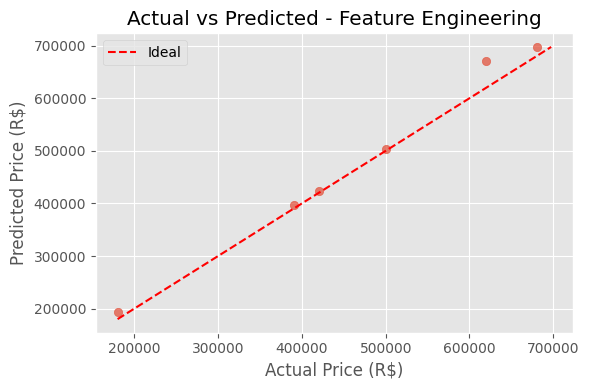

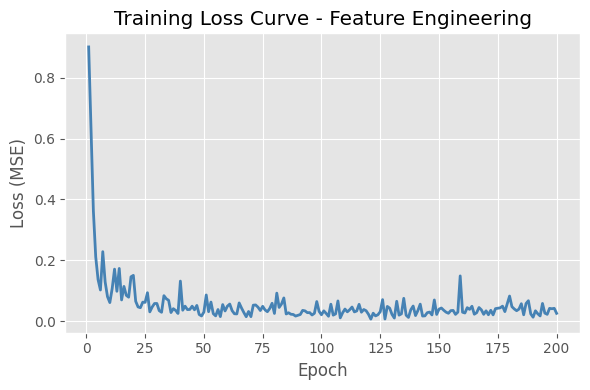

In [14]:
torch.manual_seed(SEED)
model_eng, loss_history_eng = train_model(train_loader, X_train_tensor.shape[1])
metrics_eng, errors_eng = eval_model(model_eng, X_test_tensor, y_test_tensor, scaler_y)

metrics_train_eng, metrics_test_eng = eval_train_test_metrics(
    model_eng, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, scaler_y
)

single_run_results.append({
    "title": "Feature Engineering",
    "metrics": metrics_eng,
    "errors": errors_eng
})

print("Train vs Test Metrics - Feature Engineering:")
display(pd.DataFrame([
    {"Set": "Train", **metrics_train_eng},
    {"Set": "Test", **metrics_test_eng}
]))

plot_predictions(errors_eng, " - Feature Engineering")
plot_loss_curve(loss_history_eng, " - Feature Engineering")

## 7. Model Evaluation & Strategy Comparison

This section consolidates performance results across all three preprocessing strategies.

The comparison is structured in two parts:

1. Single-run comparison: metrics from one fixed-seed training run per strategy.
2. Robustness analysis: each strategy is retrained 50 times with random seeds to assess variance and average performance.

Single-run comparison:


,Model,MSE,MAE,R2
0,Feature Encoding,1.993965e+09,37212.707031,0.925390
1,Feature Selection,1.264567e+09,27341.220703,0.952682
2,Feature Engineering,5.262442e+08,15966.549805,0.980309


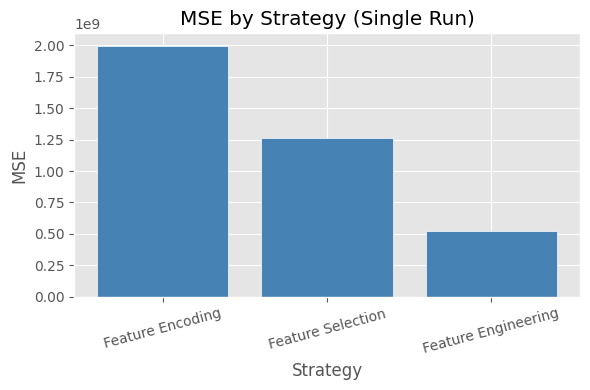

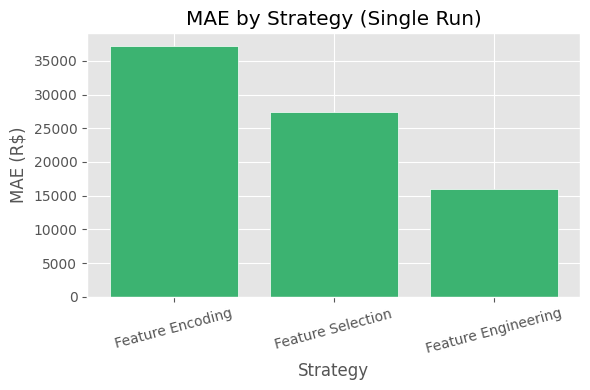

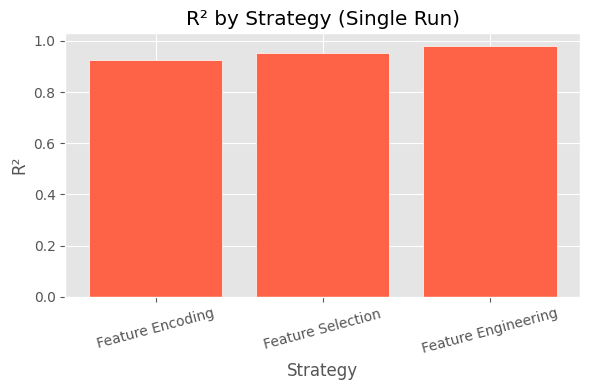

In [15]:
model_colors = {
    "Feature Encoding": "tomato",
    "Feature Selection": "mediumseagreen",
    "Feature Engineering": "steelblue"
}

df_single = pd.DataFrame([
    {
        "Model": r["title"],
        "MSE": r["metrics"]["MSE"],
        "MAE": r["metrics"]["MAE"],
        "R2": r["metrics"]["R2"]
    }
    for r in single_run_results
])

print("Single-run comparison:")
display(df_single)

plot_metric_bar(df_single, "MSE", "MSE", "MSE by Strategy (Single Run)", "steelblue")
plot_metric_bar(df_single, "MAE", "MAE (R$)", "MAE by Strategy (Single Run)", "mediumseagreen")
plot_metric_bar(df_single, "R2", "R\u00b2", "R\u00b2 by Strategy (Single Run)", "tomato")

### Robustness Analysis: 50 Training Runs

Each strategy is retrained 50 times with different random seeds. Mean MSE, MAE, and R² are reported to evaluate consistency and average performance across seeds.

In [16]:
def run_multiple_experiments(config, n_runs=50):
    """Train and evaluate the model n_runs times with random seeds; return list of metric dicts."""
    all_metrics = []
    for _ in range(n_runs):
        seed = random.randint(0, 10_000_000)
        torch.manual_seed(seed)
        np.random.seed(seed)

        loader = DataLoader(
            TensorDataset(config["X_train_tensor"], config["y_train_tensor"]),
            batch_size=16, shuffle=True
        )
        model, _ = train_model(loader, config["X_train_tensor"].shape[1])
        metrics, _ = eval_model(
            model, config["X_test_tensor"], config["y_test_tensor"], config["scaler_y"]
        )
        all_metrics.append(metrics)

    return all_metrics


multi_run_results = []
for config in preprocessing_configs:
    all_metrics = run_multiple_experiments(config, n_runs=50)
    multi_run_results.append({"title": config["title"], "metrics": all_metrics})

# Per-run DataFrame
df_runs = pd.DataFrame([
    {"Model": e["title"], "Run": i + 1, **m}
    for e in multi_run_results
    for i, m in enumerate(e["metrics"])
])

# Summary DataFrame (mean over 50 runs)
df_summary = pd.DataFrame([
    {
        "Model": e["title"],
        "MSE_mean": np.mean([m["MSE"] for m in e["metrics"]]),
        "MAE_mean": np.mean([m["MAE"] for m in e["metrics"]]),
        "R2_mean": np.mean([m["R2"] for m in e["metrics"]])
    }
    for e in multi_run_results
])

print("Mean metrics over 50 runs:")
display(df_summary)

Mean metrics over 50 runs:


,Model,MSE_mean,MAE_mean,R2_mean
0,Feature Encoding,7.925028e+08,21293.793008,0.970346
1,Feature Selection,6.751437e+08,19716.623301,0.974737
2,Feature Engineering,6.031191e+08,17207.289883,0.977432


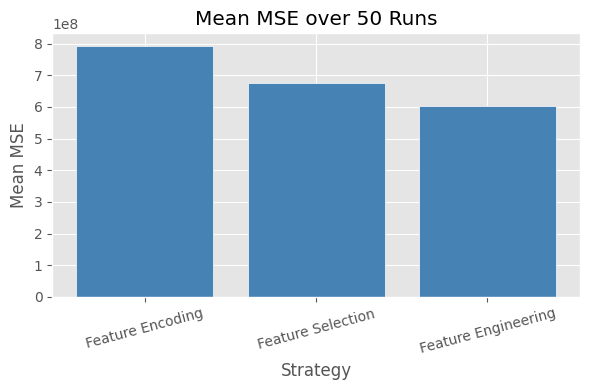

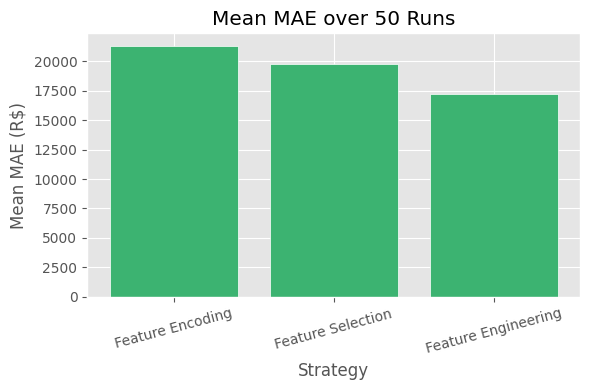

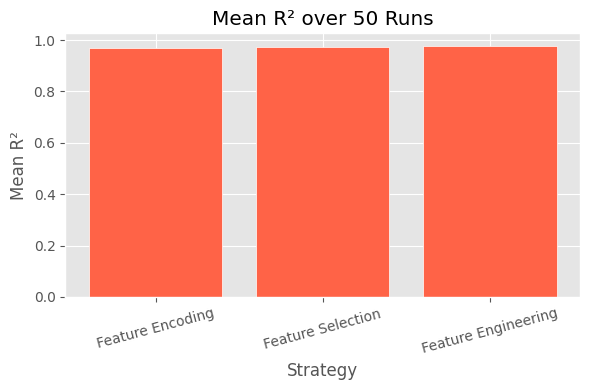

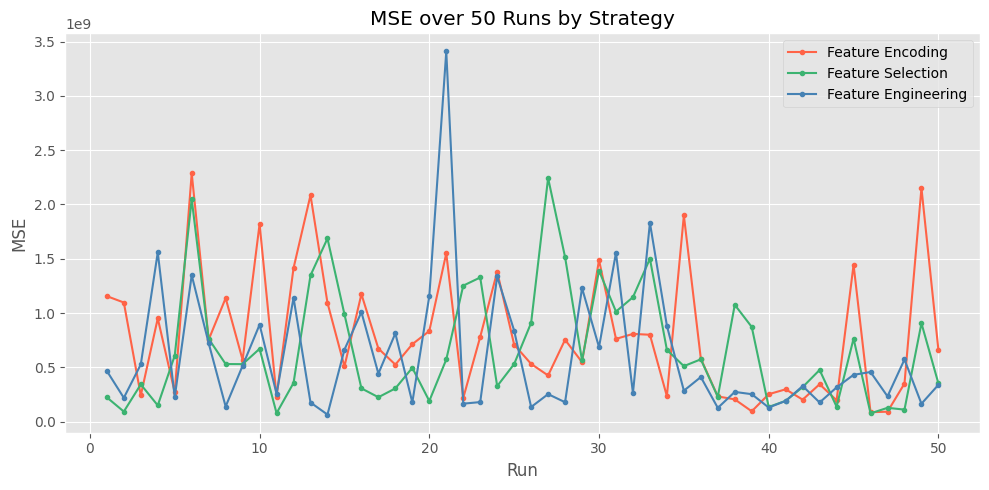

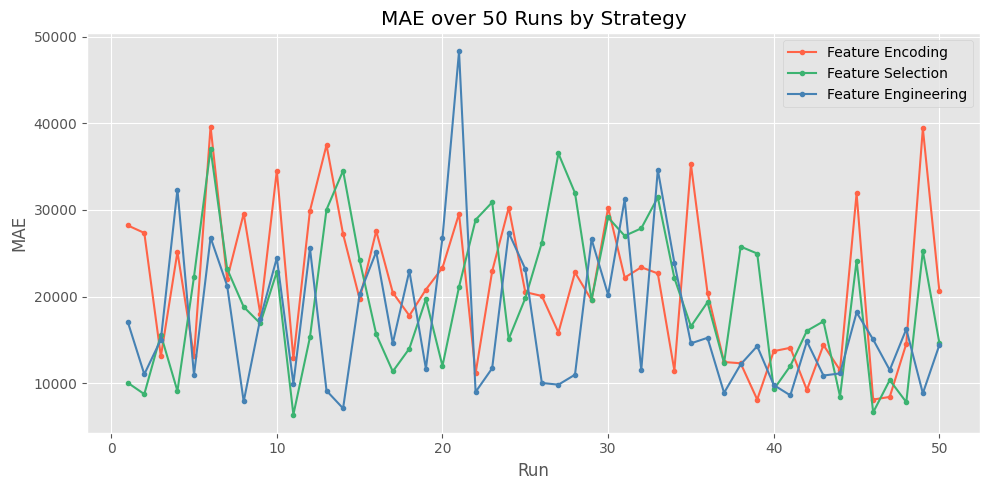

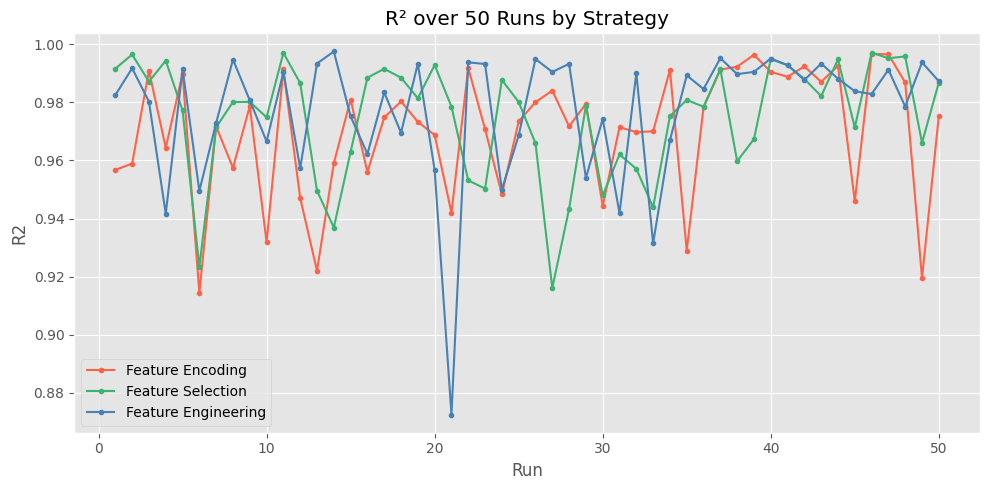

In [17]:
plot_metric_bar(df_summary, "MSE_mean", "Mean MSE", "Mean MSE over 50 Runs", "steelblue")
plot_metric_bar(df_summary, "MAE_mean", "Mean MAE (R$)", "Mean MAE over 50 Runs", "mediumseagreen")
plot_metric_bar(df_summary, "R2_mean", "Mean R\u00b2", "Mean R\u00b2 over 50 Runs", "tomato")

plot_metric_over_runs(df_runs, "MSE", "MSE over 50 Runs by Strategy", model_colors)
plot_metric_over_runs(df_runs, "MAE", "MAE over 50 Runs by Strategy", model_colors)
plot_metric_over_runs(df_runs, "R2", "R\u00b2 over 50 Runs by Strategy", model_colors)

## 8. Conclusions & Next Steps

**Key Findings**

The dataset contains only 30 samples with no missing values, which is the central limiting factor of this study. With 24 training examples after the 80/20 split, all models are highly sensitive to the specific partition and initialization seed, as confirmed by the variance observed across 50 runs.

Correlation analysis identified `Area_m2` (r=0.984), `Num_Quartos` (r=0.963), and `Num_Banheiros` (r=0.886) as the dominant positive predictors of sale price. `Idade_Casa_Anos` was the strongest negative predictor (r=-0.898). `Localizacao_A` (r=0.734) and `Localizacao_B` (r=-0.732) showed nearly symmetric influence in opposite directions, reflecting a clear price premium for zone A and a discount for zone B.

`SelectKBest` retained `Area_m2`, `Num_Quartos`, `Num_Banheiros`, `Idade_Casa_Anos`, and `Localizacao_B`, discarding `Garagem` (r=0.558) and the remaining location indicators. The selection of `Localizacao_B` over `Localizacao_A` is consistent with nearly identical F-statistics for these two binary variables given their near-equal absolute correlations.

Feature Engineering transformed `Area_m2` and `Idade_Casa_Anos` with log and square-root functions respectively, and consolidated `Num_Quartos` and `Num_Banheiros` into `Comodos_Totais`. These choices directly addressed the sub-linear scaling between area, age, and price observed in the EDA, and reduced the input space from 8 to 6 features while preserving information density.

**Model Performance vs Success Criteria**

The success criteria defined for this project were R² > 0.95 and MAE below R$ 15,000 on the test set.

In the single-run evaluation, Feature Engineering was the only strategy to satisfy the R² threshold (R²=0.980) and came closest to the MAE target (MAE=R$15,967), missing it by less than R$1,000. Feature Selection reached R²=0.953 but yielded MAE=R$27,341. Feature Encoding produced the weakest generalization with R²=0.925 and MAE=R$37,213, failing both criteria.

Across 50 training runs with random seeds, all three strategies met the R² threshold on average (Encoding=0.970, Selection=0.975, Engineering=0.977). The MAE criterion was not met by any strategy on average. Feature Engineering achieved the lowest mean MAE of R$17,207, still above the R$15,000 target.

**Interpretation**

The train-to-test MAE ratio captures the generalization quality of each strategy most clearly. Feature Encoding produced a test MAE roughly 3.1 times higher than its training MAE (R$37,213 vs R$11,850), indicating that 8 features with only 24 training samples is insufficient for the MLP to generalize. Feature Selection reduced this ratio to approximately 2.7 (R$27,341 vs R$9,985) by discarding the three lowest-relevance features. Feature Engineering achieved a ratio of approximately 1.34 (R$15,967 vs R$11,884), the best result, demonstrating that domain-informed transformations substantially improved representational efficiency.

In practical terms, a mean absolute error of R$15,967 on properties priced between R$170,000 and R$680,000 corresponds to a percentage error ranging from approximately 2 to 9 percent across the observed price range. This is adequate for exploratory pricing models but insufficient for high-stakes valuation contexts.

**Limitations**

- The dataset contains only 30 samples. The test set consists of 6 properties, making single-run metrics highly sensitive to which samples fall in the test partition. The 50-run analysis partially mitigates this but does not substitute for a larger dataset.
- The synthetic nature of the data means feature distributions and correlations may not reflect real-world market dynamics, limiting the generalizability of the conclusions.
- The MLP architecture (32, 16 units) is over-parameterized relative to the training set size, which contributes to the overfitting observed in strategies 1 and 2. Dropout at p=0.1 provides only light regularization and is insufficient to control this at the given sample size.
- The evaluation protocol uses a single fixed train/test split per run, meaning the reported metrics reflect performance on one particular subset of 6 test samples.

**Next Steps**

- Expand the dataset to at least several hundred samples. At 30 observations, no model or preprocessing strategy can be reliably evaluated or compared.
- Replace the single train/test split with k-fold cross-validation (k=5 or leave-one-out) to obtain more stable and statistically meaningful performance estimates.
- Evaluate simpler, regularized models such as Ridge regression or a shallow Random Forest with limited depth. At this sample size, such models are expected to outperform a neural network.
- Increase regularization in the MLP, either by raising dropout probability to 0.2 or 0.3, or by increasing the weight decay parameter.
- Extend feature engineering with interaction terms such as `Area_m2` per `Comodos_Totais` (room density) or location-area cross features, which may capture pricing non-linearities not yet represented.
- Apply systematic hyperparameter tuning over learning rate, architecture width, and batch size using a validation split.